In [ ]:
import pandas as pd
import cv2

imagenet_classes = pd.read_csv(
    'input_data/imagenet_classes.txt',
     delimiter = ',',
     names = ['class_index', 'class_name']
)



imagenet_classes.head(500)

,class_index,class_name
0,0,tench
1,1,goldfish
2,2,great_white_shark
3,3,tiger_shark
4,4,hammerhead
...,...,...
495,495,china_cabinet
496,496,Christmas_stocking
497,497,church
498,498,cinema


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

In [ ]:
torch.manual_seed(42)  # Set seed for reproducibility
torch.backends.cudnn.deterministic = True  # Enforce deterministic convolution
torch.backends.cudnn.benchmark = False  # Disable cuDNN benchmarking


In [ ]:
# Load the pretrained AlexNet model
m_alexnet = models.alexnet(pretrained=True)

# Get the pretrained weights of the first layer
pretrained_weights = m_alexnet.features[0].weight.data.clone()

# Create a new Conv2d layer with 1 input channel
new_conv = nn.Conv2d(1, 64, kernel_size=11, stride=4, padding=2)

# Initialize the new weights
with torch.no_grad():
    # Average the pretrained weights across the RGB channels
    new_conv.weight = nn.Parameter(pretrained_weights.mean(dim=1, keepdim=True))

# Replace the first layer with the new convolutional layer
m_alexnet.features[0] = new_conv



/home/jaykumaran/miniconda3/envs/torch_2x/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jaykumaran/miniconda3/envs/torch_2x/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
import torch
from torchvision import models, transforms
from PIL import Image

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the original AlexNet model
original_model = models.alexnet(pretrained=True).to(device)
original_model.eval()

# Load the modified AlexNet model (ensure you have your modified version here)
modified_model = m_alexnet.to(device)
modified_model.eval()

# Define the transformation pipeline for inference
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load a sample image for inference
def load_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")  # Ensure RGB mode
    return transform(image).unsqueeze(0)  # Add batch dimension

# Load a sample image for inference (Grayscale)
def load_image_grayscale(image_path):
    transform_grayscale = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485], std=[0.229]),  # Adjust for single-channel input
    ])
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale (1 channel)
    image = Image.fromarray(image)
    return transform_grayscale(image).unsqueeze(0)  # Add batch dimension

image_path = "/home/jaykumaran/Downloads/n01443537_goldfish.JPEG"  # Replace with your image path
input_tensor = load_image(image_path, transform).to(device)

grayscale_image_tensor = load_image_grayscale(image_path).to(device)

# Inference on the original model
with torch.no_grad():
    original_output = original_model(input_tensor)
    original_pred_class = torch.argmax(original_output, dim=1).item()

# Inference on the modified model
with torch.no_grad():
    modified_output = modified_model(grayscale_image_tensor)
    modified_pred_class = torch.argmax(modified_output, dim=1).item()

# Print the predicted class IDs
print(f"Original Model Predicted Class ID: {original_pred_class}")
print("Class name:", imagenet_classes.loc[original_pred_class, 'class_name'])


print( " *********************************************")
print(f"Modified Model Predicted Class ID: {modified_pred_class}")
print("Class name:", imagenet_classes.loc[modified_pred_class, 'class_name'])


/home/jaykumaran/miniconda3/envs/torch_2x/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jaykumaran/miniconda3/envs/torch_2x/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Original Model Predicted Class ID: 1
Class name:  goldfish
 *********************************************
Modified Model Predicted Class ID: 126
Class name:  isopod


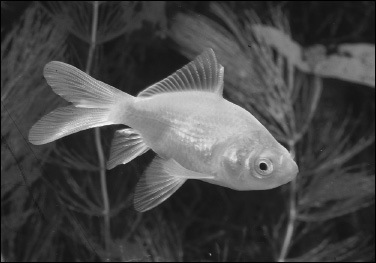

In [ ]:
image = Image.open(image_path).convert("L")  # Convert to grayscale
image

#

Grayscale with 3 channels for OG Model

In [ ]:
# Define the transformation pipeline for inference
transform = transforms.Compose([

    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load a grayscale image and convert it to 3 channels
def load_grayscale_as_rgb(image_path, transform):
    image = cv2.cvtColor(cv2.imread(image_path, cv2.IMREAD_GRAYSCALE), cv2.COLOR_GRAY2RGB)  # Convert to grayscale (1 channel)
    image = Image.fromarray(image)
    return transform(image).unsqueeze(0)  # Apply transformations and add batch dimension

image_path = "/home/jaykumaran/Downloads/n01443537_goldfish.JPEG"  # Replace with your image path

# Load the grayscale image as 3-channel input
input_tensor = load_grayscale_as_rgb(image_path, transform).to(device)

# Inference on the original model
with torch.no_grad():
    original_output = original_model(input_tensor)
    original_pred_class = torch.argmax(original_output, dim=1).item()

# Print the predicted class ID for the original model
print(f"Original Model Predicted Class ID (Grayscale replicated as RGB): {original_pred_class}")
print("**************************")
print("Class name:", imagenet_classes.loc[original_pred_class, 'class_name'])


Original Model Predicted Class ID (Grayscale replicated as RGB): 947
**************************
Class name:  mushroom
